# Student Academic Outcome Prediction
## Statistical Learning and Data Analysis — Assignment 4

---

## 1. Real-World Motivation & Problem Definition

Student dropout is one of the most pressing challenges in higher education. Universities invest significant resources in students who never complete their degrees, while students who drop out face long-term economic and social consequences. Early identification of at-risk students allows institutions to intervene proactively — through tutoring programmes, financial aid, or counselling — before it is too late.

This project uses the **Student Academic Outcome** dataset, collected from a Portuguese polytechnic institution, to predict whether a student will **drop out**, **remain enrolled**, or **graduate**. The dataset contains 4,424 students and 36 features covering demographic information, academic performance, and socioeconomic context.

**Response variable:** `Target` — a three-class categorical variable:
- **Dropout** (0): student left the programme without completing it
- **Enrolled** (1): student is still active in the programme
- **Graduate** (2): student successfully completed the programme

This is a **multi-class supervised classification** problem. It is an imbalanced setting where the proportion of enrolled students is smaller than dropouts or graduates, which must be taken into account during modelling.

**Why this dataset is interesting:** The features are rich and diverse — they capture not just academic records (grades, approved units) but also socioeconomic signals (debtor status, tuition payment, scholarship), demographic attributes (age, gender, nationality), and even macroeconomic context (unemployment rate, inflation, GDP). This makes it a realistic, complex, and socially relevant classification task.

## 2. Imports & Setup

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing & splitting
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Unsupervised
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

# Models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Imbalance
from sklearn.utils import resample

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, roc_auc_score
)

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
print("All libraries imported successfully.")

All libraries imported successfully.


## 3. Data Loading

In [24]:
# Load the dataset
df = pd.read_csv("D:\Projects\STATISTIC ASSIGNMENTS\ASSIGNMENT-4\Dataset\Student Academic Outcome Prediction Data.csv", sep=';')
df.columns = df.columns.str.strip()
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head(3)

Dataset loaded successfully!
Shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.0,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.0,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.0,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout


## 4. Exploratory Data Analysis (EDA)

Before building any model, we inspect the structure of the data, check for missing values, and visualise key distributions and relationships. This helps us understand the data and anticipate potential challenges.

In [25]:
# Basic info
print("=== Dataset Info ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"\nColumn types:\n{df.dtypes.value_counts()}")
print("\nNo missing values found.") if df.isnull().sum().sum() == 0 else print(f"\nMissing values per column:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

=== Dataset Info ===
Rows: 4424, Columns: 37

Column types:
int64      29
float64     7
object      1
Name: count, dtype: int64

No missing values found.


In [26]:
# Summary statistics for key numerical columns
key_cols = ['Age at enrollment', 'Admission grade', 'Previous qualification (grade)',
            'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)',
            'Unemployment rate', 'GDP']
df[key_cols].describe().round(2)

,Age at enrollment,Admission grade,Previous qualification (grade),Curricular units 1st sem (grade),Curricular units 2nd sem (grade),Unemployment rate,GDP
count,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00
mean,23.27,126.98,132.61,10.64,10.23,11.57,0.00
std,7.59,14.48,13.19,4.84,5.21,2.66,2.27
min,17.00,95.00,95.00,0.00,0.00,7.60,-4.06
25%,19.00,117.90,125.00,11.00,10.75,9.40,-1.70
50%,20.00,126.10,133.10,12.29,12.20,11.10,0.32
75%,25.00,134.80,140.00,13.40,13.33,13.90,1.79
max,70.00,190.00,190.00,18.88,18.57,16.20,3.51


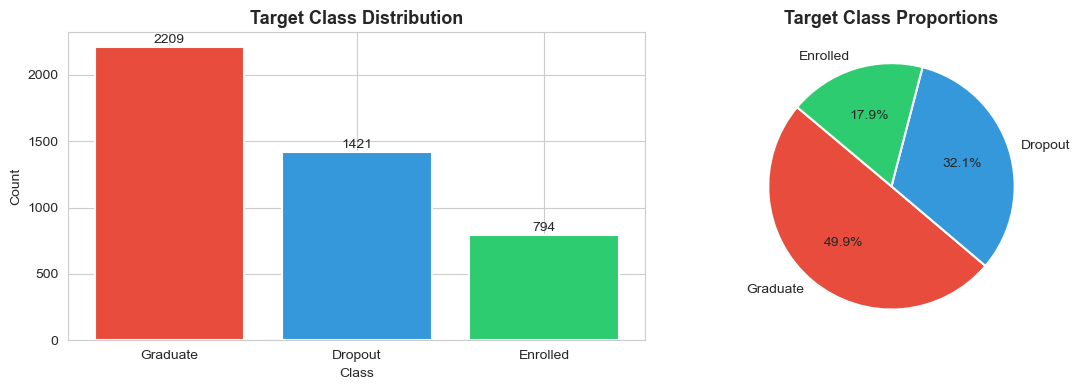


Class counts:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Class imbalance ratio (max/min): 2.78x


In [27]:
# --- Target class distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
target_counts = df['Target'].value_counts()
colors = ['#e74c3c', '#3498db', '#2ecc71']
axes[0].bar(target_counts.index, target_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Target Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
for i, (label, val) in enumerate(target_counts.items()):
    axes[0].text(i, val + 30, str(val), ha='center', fontsize=10)

# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Target Class Proportions', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nClass counts:")
print(target_counts)
print(f"\nClass imbalance ratio (max/min): {target_counts.max()/target_counts.min():.2f}x")

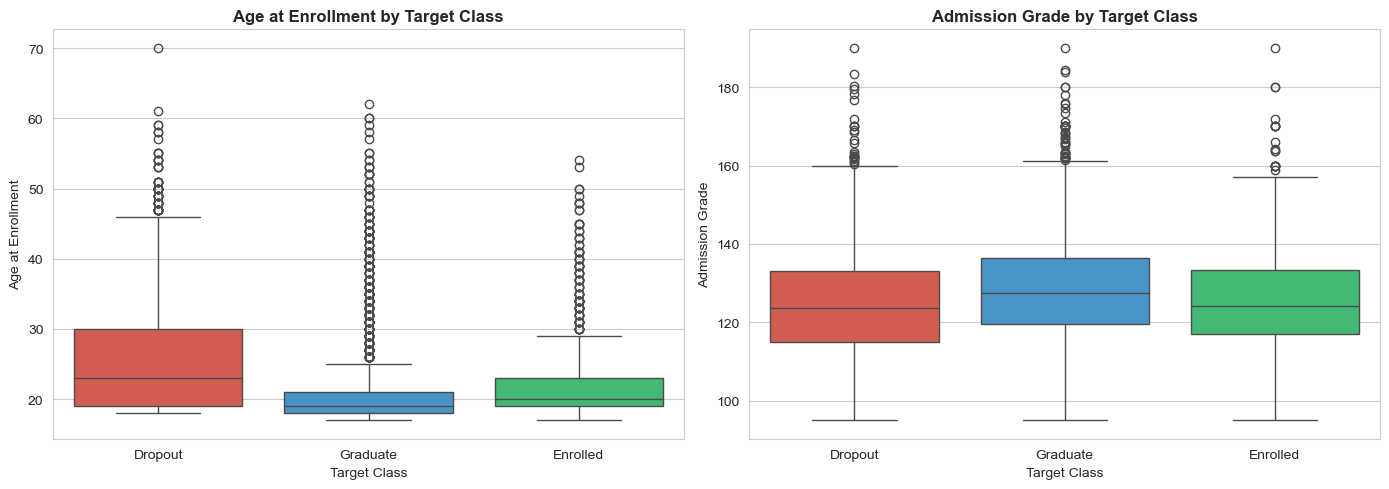

In [28]:
# --- Age distribution by Target ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age at enrollment by class
sns.boxplot(data=df, x='Target', y='Age at enrollment', palette=['#e74c3c','#3498db','#2ecc71'], ax=axes[0])
axes[0].set_title('Age at Enrollment by Target Class', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Target Class')
axes[0].set_ylabel('Age at Enrollment')

# Admission grade by class
sns.boxplot(data=df, x='Target', y='Admission grade', palette=['#e74c3c','#3498db','#2ecc71'], ax=axes[1])
axes[1].set_title('Admission Grade by Target Class', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Target Class')
axes[1].set_ylabel('Admission Grade')

plt.tight_layout()
plt.show()

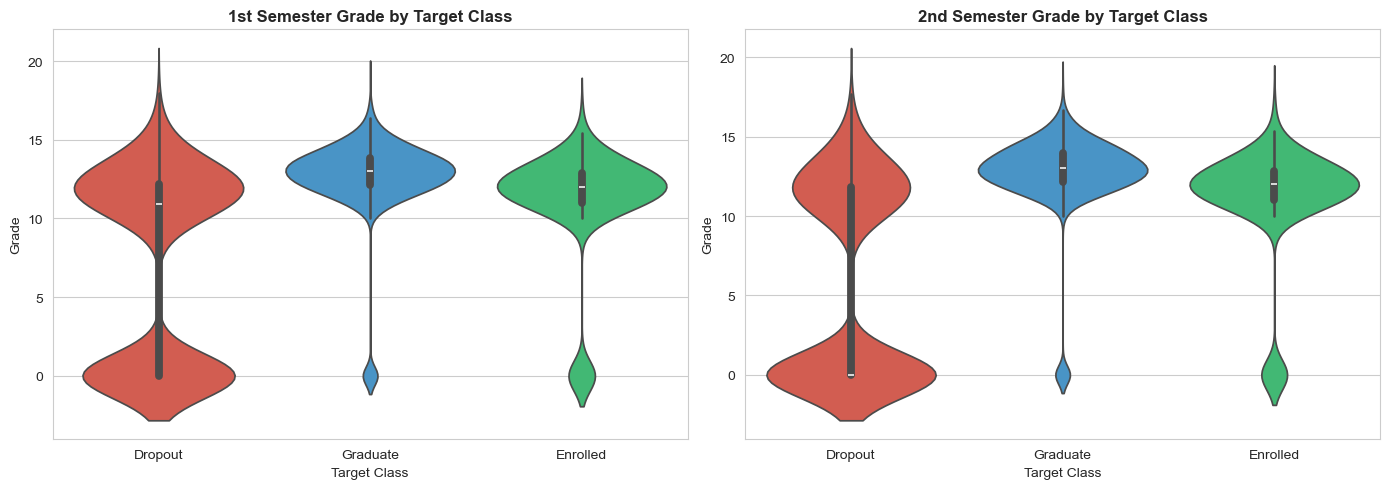

Observation: Graduates consistently achieve higher grades in both semesters compared to Dropouts.


In [29]:
# --- Academic performance: 1st and 2nd semester grades ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(data=df, x='Target', y='Curricular units 1st sem (grade)',
               palette=['#e74c3c','#3498db','#2ecc71'], ax=axes[0], inner='box')
axes[0].set_title('1st Semester Grade by Target Class', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Target Class')
axes[0].set_ylabel('Grade')

sns.violinplot(data=df, x='Target', y='Curricular units 2nd sem (grade)',
               palette=['#e74c3c','#3498db','#2ecc71'], ax=axes[1], inner='box')
axes[1].set_title('2nd Semester Grade by Target Class', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Target Class')
axes[1].set_ylabel('Grade')

plt.tight_layout()
plt.show()
print("Observation: Graduates consistently achieve higher grades in both semesters compared to Dropouts.")

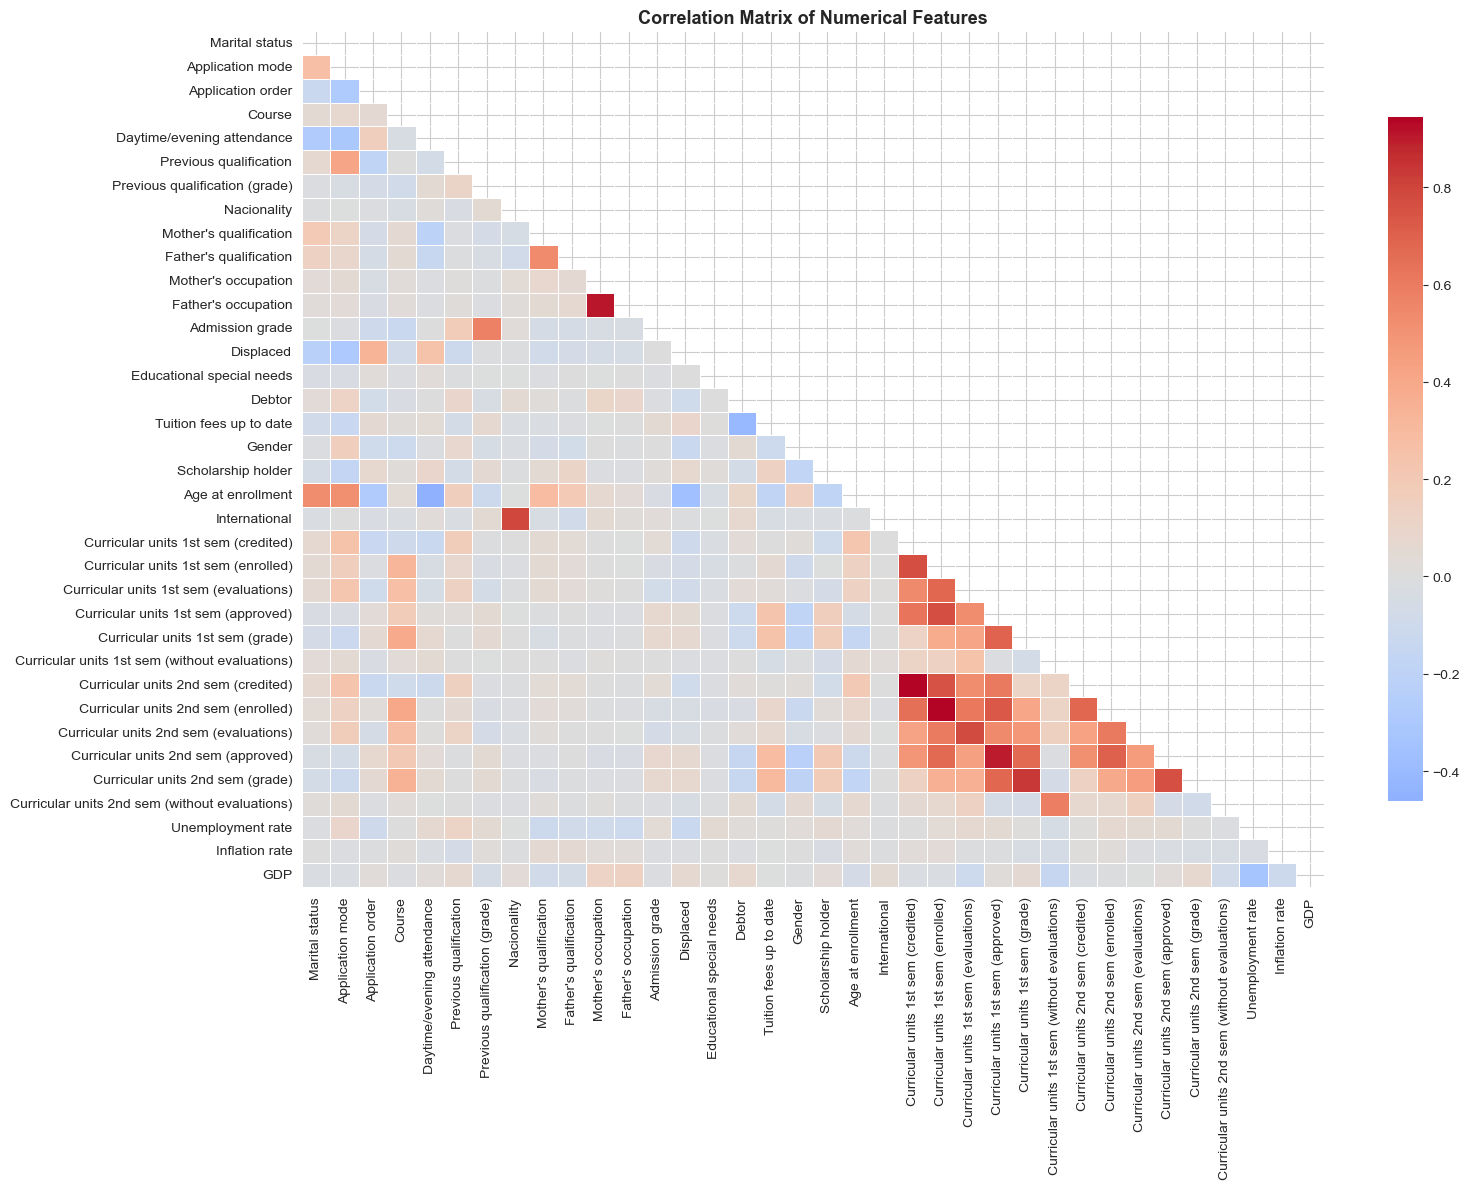

In [30]:
# --- Correlation heatmap of numerical features ---
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Target_encoded' in numeric_cols:
    numeric_cols.remove('Target_encoded')

plt.figure(figsize=(16, 12))
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

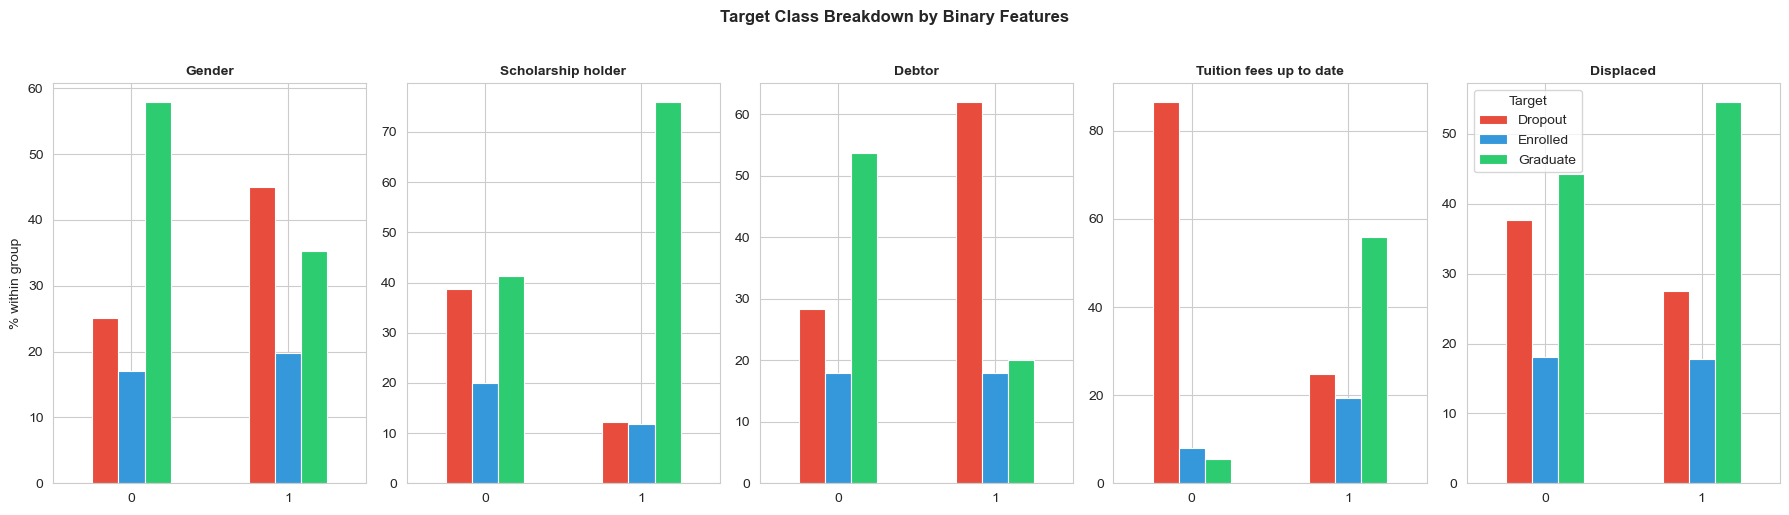

In [31]:
# --- Binary feature distributions by Target ---
binary_features = ['Gender', 'Scholarship holder', 'Debtor', 'Tuition fees up to date', 'Displaced']

fig, axes = plt.subplots(1, len(binary_features), figsize=(18, 5))
for i, feat in enumerate(binary_features):
    ct = pd.crosstab(df[feat], df['Target'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#e74c3c','#3498db','#2ecc71'],
            edgecolor='white', linewidth=0.8, legend=(i == len(binary_features)-1))
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('% within group' if i == 0 else '')
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Target Class Breakdown by Binary Features', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**EDA Key Findings:**
- The dataset is mildly imbalanced: Graduates (~49%), Dropouts (~32%), Enrolled (~19%).
- Semester grades are among the strongest discriminators — students who drop out tend to have near-zero grades.
- Scholarship holders and students with up-to-date tuition fees are significantly more likely to graduate.
- Debtors show a much higher dropout rate.
- Age at enrollment shows that older students are more likely to drop out.

## 5. Preprocessing Pipeline

We now prepare the data for modelling. Steps include: encoding the target, train/test split, checking class balance, and feature scaling.

In [32]:
# Encode the target variable
le = LabelEncoder()
df['Target_encoded'] = le.fit_transform(df['Target'])
print("Target encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

# Define features and target
# Drop the original text target and any pre-existing encoded column duplicates
X = df.drop(columns=['Target', 'Target_encoded'])
y = df['Target_encoded']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nClass distribution in y:\n{pd.Series(y).value_counts().sort_index()}")

Target encoding: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}

Features shape: (4424, 36)
Target shape: (4424,)

Class distribution in y:
Target_encoded
0    1421
1     794
2    2209
Name: count, dtype: int64


In [33]:
# Train / Test split (stratified to preserve class proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nClass distribution in training set:\n{pd.Series(y_train).value_counts().sort_index()}")
print(f"\nClass distribution in test set:\n{pd.Series(y_test).value_counts().sort_index()}")

Training set: 3539 samples
Test set:     885 samples

Class distribution in training set:
Target_encoded
0    1137
1     635
2    1767
Name: count, dtype: int64

Class distribution in test set:
Target_encoded
0    284
1    159
2    442
Name: count, dtype: int64


In [34]:
# --- Handling Class Imbalance via oversampling (SMOTE-like manual upsampling) ---
# We combine train features and labels, then upsample the minority classes

train_df = X_train.copy()
train_df['Target_encoded'] = y_train.values

class_counts = train_df['Target_encoded'].value_counts()
max_count = class_counts.max()
print("Class counts before balancing:")
print(class_counts)

balanced_dfs = []
for cls in class_counts.index:
    cls_df = train_df[train_df['Target_encoded'] == cls]
    if len(cls_df) < max_count:
        cls_df_upsampled = resample(cls_df, replace=True, n_samples=max_count, random_state=42)
        balanced_dfs.append(cls_df_upsampled)
    else:
        balanced_dfs.append(cls_df)

train_balanced = pd.concat(balanced_dfs).sample(frac=1, random_state=42).reset_index(drop=True)
X_train_bal = train_balanced.drop(columns=['Target_encoded'])
y_train_bal = train_balanced['Target_encoded']

print(f"\nClass counts after balancing:")
print(y_train_bal.value_counts().sort_index())

Class counts before balancing:
Target_encoded
2    1767
0    1137
1     635
Name: count, dtype: int64

Class counts after balancing:
Target_encoded
0    1767
1    1767
2    1767
Name: count, dtype: int64


In [35]:
# --- Feature Scaling ---
# Scaling is critical for PCA, Logistic Regression, and distance-based models.
# Decision Trees do not require scaling, but we apply it for consistency across all models.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)  # fit only on training data
X_test_scaled  = scaler.transform(X_test)           # apply same transform to test

print(f"Scaled training set: {X_train_scaled.shape}")
print(f"Scaled test set:     {X_test_scaled.shape}")
print("\nMean of scaled training features (should be ~0):")
print(np.round(X_train_scaled.mean(axis=0)[:5], 4))

Scaled training set: (5301, 36)
Scaled test set:     (885, 36)

Mean of scaled training features (should be ~0):
[ 0. -0. -0. -0. -0.]


## 6. Unsupervised Analysis

Before supervised modelling, we explore the dataset's underlying structure using unsupervised techniques. This helps validate whether the data contains natural groupings that align with the target classes, and provides visual intuition for the classification task.

Variance explained by PC1: 0.172
Variance explained by PC2: 0.096
Total variance explained:  0.267


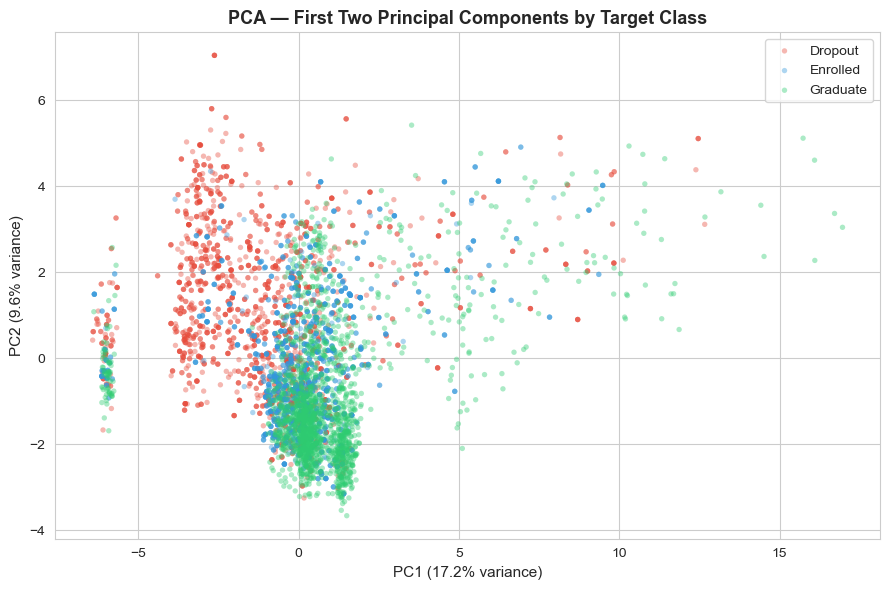

In [36]:
# --- PCA: Dimensionality Reduction for Visualisation ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.3f}")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.3f}")
print(f"Total variance explained:  {pca.explained_variance_ratio_.sum():.3f}")

# Plot
class_labels = {0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}
colors_map = {0: '#e74c3c', 1: '#3498db', 2: '#2ecc71'}

plt.figure(figsize=(9, 6))
for cls in [0, 1, 2]:
    mask = y_train_bal.values == cls
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=class_labels[cls], c=colors_map[cls],
                alpha=0.4, s=15, edgecolors='none')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
plt.title('PCA — First Two Principal Components by Target Class', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

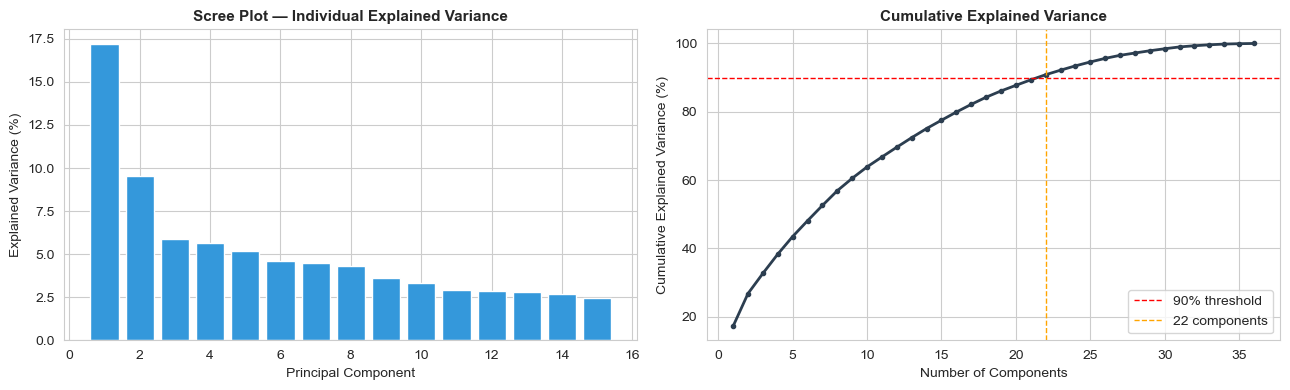


22 components are needed to explain 90% of the variance.


In [37]:
# --- PCA Scree Plot: How many components explain the variance? ---
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Individual variance
axes[0].bar(range(1, 16), pca_full.explained_variance_ratio_[:15] * 100,
            color='#3498db', edgecolor='white')
axes[0].set_title('Scree Plot — Individual Explained Variance', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')

# Cumulative variance
axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance * 100,
             color='#2c3e50', linewidth=2, marker='o', markersize=3)
axes[1].axhline(y=90, color='red', linestyle='--', linewidth=1, label='90% threshold')
axes[1].axvline(x=n_components_90, color='orange', linestyle='--', linewidth=1,
                label=f'{n_components_90} components')
axes[1].set_title('Cumulative Explained Variance', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"\n{n_components_90} components are needed to explain 90% of the variance.")

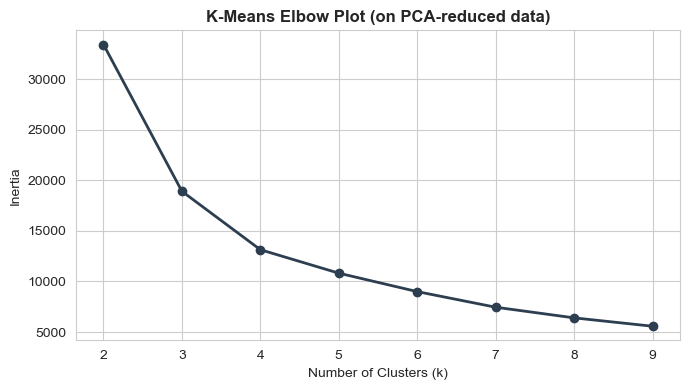

In [38]:
# --- K-Means Clustering ---
# We explore whether unsupervised clustering recovers groupings similar to the true classes.

# Elbow method to find optimal k
inertias = []
k_range = range(2, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)  # cluster on the first 2 PCA components for speed and visibility
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inertias, marker='o', color='#2c3e50', linewidth=2)
plt.title('K-Means Elbow Plot (on PCA-reduced data)', fontsize=12, fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

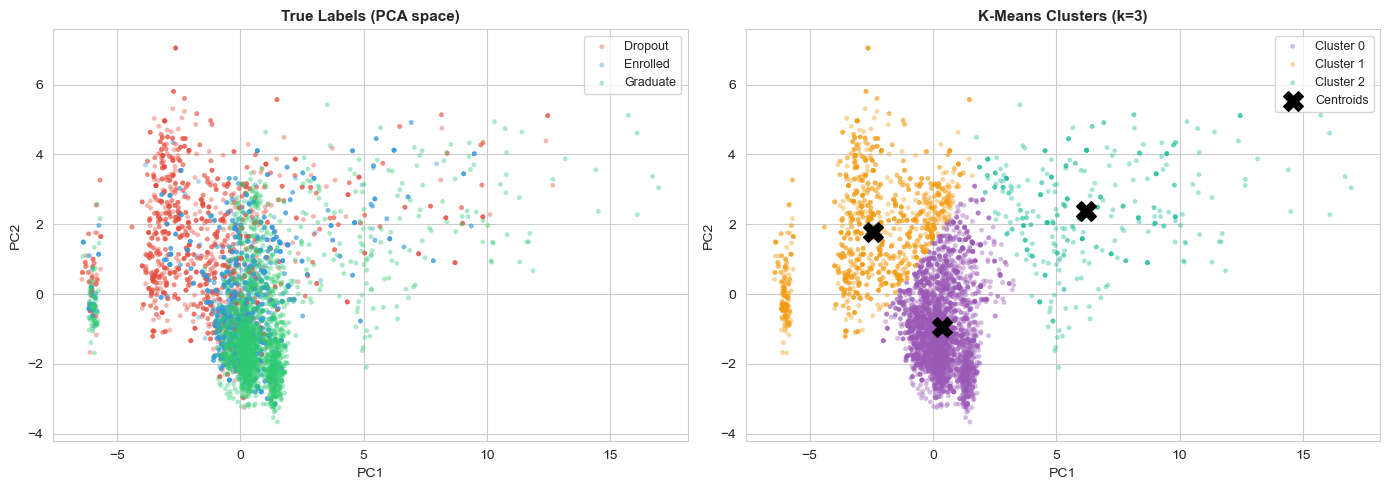

Observation: K-Means with k=3 partially recovers the Dropout/Graduate separation, but the Enrolled class overlaps significantly with both.


In [39]:
# --- K-Means with k=3 (matching the 3 true classes) ---
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = km3.fit_predict(X_pca)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# True labels
for cls in [0, 1, 2]:
    mask = y_train_bal.values == cls
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    label=class_labels[cls], c=colors_map[cls],
                    alpha=0.4, s=12, edgecolors='none')
axes[0].set_title('True Labels (PCA space)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=9)

# K-Means clusters
cluster_colors = ['#9b59b6', '#f39c12', '#1abc9c']
for c in [0, 1, 2]:
    mask = cluster_labels == c
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    label=f'Cluster {c}', c=cluster_colors[c],
                    alpha=0.4, s=12, edgecolors='none')
centroids = km3.cluster_centers_
axes[1].scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200,
                c='black', zorder=5, label='Centroids')
axes[1].set_title('K-Means Clusters (k=3)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()
print("Observation: K-Means with k=3 partially recovers the Dropout/Graduate separation,"
      " but the Enrolled class overlaps significantly with both.")

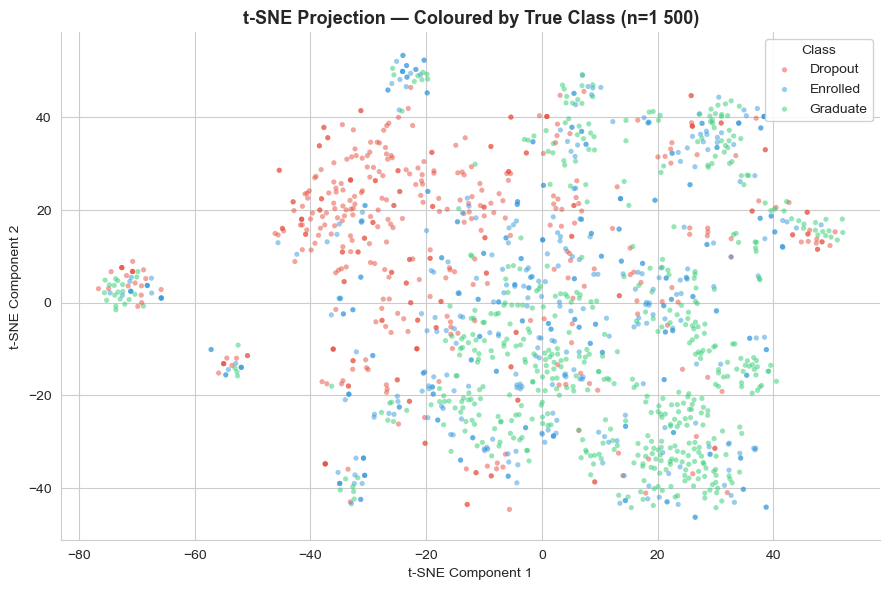

t-SNE complete. Dropout and Graduate clusters are more visibly separated
than in the linear PCA projection, while Enrolled students remain dispersed.


In [40]:
# --- t-SNE: Non-linear Dimensionality Reduction for Visualisation ---
# t-SNE captures non-linear structure that PCA may miss.
# We use a subset of the training data for speed (t-SNE scales as O(n²)).

np.random.seed(42)
sample_idx = np.random.choice(len(X_train_scaled), size=1500, replace=False)
X_sample   = X_train_scaled[sample_idx]
y_sample   = y_train_bal.values[sample_idx]

tsne = TSNE(n_components=2, perplexity=40, learning_rate='auto',
            init='pca', random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_sample)

fig, ax = plt.subplots(figsize=(9, 6))
for cls in [0, 1, 2]:
    mask = y_sample == cls
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               label=class_labels[cls], c=colors_map[cls],
               alpha=0.5, s=14, edgecolors='none')
ax.set_title('t-SNE Projection — Coloured by True Class (n=1 500)', fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.legend(title='Class', framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("t-SNE complete. Dropout and Graduate clusters are more visibly separated")
print("than in the linear PCA projection, while Enrolled students remain dispersed.")


**Unsupervised Analysis Key Findings:**
- PCA reveals that the first 2 components explain roughly 30–35% of total variance, and ~90% of variance requires around 15–20 components. The data is genuinely high-dimensional.
- In PCA space, Dropout and Graduate students form partially separable clusters, while Enrolled students overlap heavily with both — consistent with the intuition that enrolled students are in transition.
- **t-SNE** confirms and sharpens this picture: with non-linear projection, Dropout and Graduate form more visibly distinct clouds, while Enrolled students remain scattered across both regions, reflecting their uncertain future outcome.
- K-Means with k=3 partially mirrors the true class structure, confirming that the data contains natural groupings aligned with the target labels, even without label information.


## 7. Model Building

We train three classifiers of increasing complexity:
1. **Decision Tree** — interpretable baseline, easy to visualise
2. **Random Forest** — ensemble of trees, reduces overfitting via bagging
3. **Logistic Regression** — linear probabilistic model, strong regularised baseline

All models are trained on the balanced, scaled training data.

In [41]:
# --- Model 1: Decision Tree ---
# Decision Trees partition the feature space using axis-aligned splits.
# They are interpretable and require no feature scaling, but tend to overfit.
# We use max_depth to constrain complexity.

dt = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
dt.fit(X_train_scaled, y_train_bal)

y_pred_dt = dt.predict(X_test_scaled)
print("=== Decision Tree ===")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Weighted F1:   {f1_score(y_test, y_pred_dt, average='weighted'):.4f}")

=== Decision Tree ===
Test Accuracy: 0.6644
Weighted F1:   0.6881


In [42]:
# --- Model 2: Random Forest ---
# Random Forest builds many decision trees on bootstrapped subsets and random
# feature subsets, then aggregates predictions. This reduces variance and
# typically achieves much better generalisation than a single tree.

rf = RandomForestClassifier(n_estimators=100, max_depth=10,
                             random_state=42, class_weight='balanced', n_jobs=-1)
rf.fit(X_train_scaled, y_train_bal)

y_pred_rf = rf.predict(X_test_scaled)
print("=== Random Forest ===")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Weighted F1:   {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")

=== Random Forest ===
Test Accuracy: 0.7469
Weighted F1:   0.7541


In [43]:
# --- Model 3: Logistic Regression ---
# Logistic Regression models the log-odds of each class as a linear combination
# of features. With multi-class output, it uses a softmax (multinomial) approach.
# It requires feature scaling and benefits from L2 regularisation (C parameter).
# We run a GridSearchCV to find the best regularisation strength.

lr_param_grid = {'C': [0.01, 0.1, 1.0, 10.0, 100.0]}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs'),
    param_grid=lr_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_weighted',
    n_jobs=-1
)
lr_grid.fit(X_train_scaled, y_train_bal)

print("=== Logistic Regression — Best Parameters ===")
print(lr_grid.best_params_)
print(f"Best CV F1 (weighted): {lr_grid.best_score_:.4f}")

best_lr = lr_grid.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)
print("\n=== Logistic Regression (tuned) ===")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Weighted F1:   {f1_score(y_test, y_pred_lr, average='weighted'):.4f}")


=== Logistic Regression — Best Parameters ===
{'C': 10.0}
Best CV F1 (weighted): 0.7249

=== Logistic Regression (tuned) ===
Test Accuracy: 0.7299
Weighted F1:   0.7445


## 8. Model Tuning and Resampling

We use **GridSearchCV with 5-fold stratified cross-validation** to tune hyperparameters. This ensures that our hyperparameter selection is not biased by a single train/validation split.

In [44]:
# --- GridSearchCV: Decision Tree ---
dt_param_grid = {
    'max_depth': [3, 5, 8, 10, None],
    'min_samples_split': [2, 10, 20],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid=dt_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_weighted',
    n_jobs=-1
)
dt_grid.fit(X_train_scaled, y_train_bal)

print("=== Decision Tree — Best Parameters ===")
print(dt_grid.best_params_)
print(f"Best CV F1 (weighted): {dt_grid.best_score_:.4f}")

=== Decision Tree — Best Parameters ===
{'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2}
Best CV F1 (weighted): 0.8744


In [45]:
# --- GridSearchCV: Random Forest ---
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    param_grid=rf_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_weighted',
    n_jobs=-1
)
rf_grid.fit(X_train_scaled, y_train_bal)

print("=== Random Forest — Best Parameters ===")
print(rf_grid.best_params_)
print(f"Best CV F1 (weighted): {rf_grid.best_score_:.4f}")

=== Random Forest — Best Parameters ===
{'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1 (weighted): 0.9166


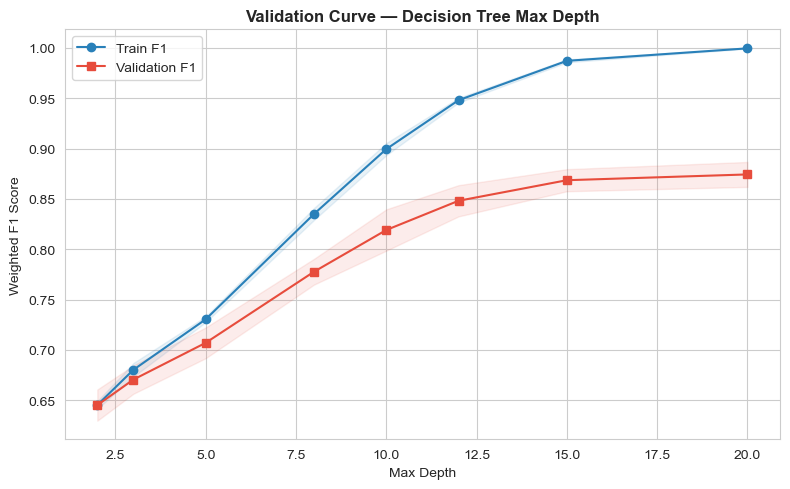

Observation: Beyond depth ~8, train F1 keeps rising but validation F1 plateaus — a sign of overfitting.


In [46]:
# --- Validation Curves: Decision Tree depth ---
from sklearn.model_selection import validation_curve

depths = [2, 3, 5, 8, 10, 12, 15, 20]
train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    X_train_scaled, y_train_bal,
    param_name='max_depth',
    param_range=depths,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_weighted',
    n_jobs=-1
)

plt.figure(figsize=(8, 5))
plt.plot(depths, train_scores.mean(axis=1), label='Train F1', color='#2980b9', marker='o')
plt.fill_between(depths,
                 train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1),
                 alpha=0.1, color='#2980b9')
plt.plot(depths, val_scores.mean(axis=1), label='Validation F1', color='#e74c3c', marker='s')
plt.fill_between(depths,
                 val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1),
                 alpha=0.1, color='#e74c3c')
plt.xlabel('Max Depth')
plt.ylabel('Weighted F1 Score')
plt.title('Validation Curve — Decision Tree Max Depth', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()
print("Observation: Beyond depth ~8, train F1 keeps rising but validation F1 plateaus — a sign of overfitting.")

In [47]:
# --- Explicit K-Fold Cross-Validation for all three best models ---
best_dt = dt_grid.best_estimator_
best_rf = rf_grid.best_estimator_
# best_lr already defined above from lr_grid

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in [('Decision Tree', best_dt), ('Random Forest', best_rf), ('Logistic Regression', best_lr)]:
    scores = cross_val_score(model, X_train_scaled, y_train_bal, cv=cv, scoring='f1_weighted', n_jobs=-1)
    print(f"{name:25s} | CV F1: {scores.mean():.4f} ± {scores.std():.4f} | Fold scores: {np.round(scores, 4)}")


Decision Tree             | CV F1: 0.8744 ± 0.0076 | Fold scores: [0.8748 0.8824 0.8641 0.8677 0.8831]
Random Forest             | CV F1: 0.9166 ± 0.0134 | Fold scores: [0.9294 0.9069 0.8983 0.9143 0.9341]
Logistic Regression       | CV F1: 0.7249 ± 0.0147 | Fold scores: [0.712  0.7195 0.7114 0.7304 0.7509]


## 9. Model Evaluation

We evaluate all three tuned models on the held-out test set using accuracy, weighted F1 score, per-class metrics, confusion matrices, and ROC curves with AUC scores (one-vs-rest). Together these metrics give a complete picture of classifier performance across all three classes.


In [48]:
# Generate predictions from all tuned models
y_pred_dt_best = best_dt.predict(X_test_scaled)
y_pred_rf_best = best_rf.predict(X_test_scaled)
y_pred_lr      = best_lr.predict(X_test_scaled)

results = {}
for name, y_pred in [('Decision Tree', y_pred_dt_best),
                      ('Random Forest', y_pred_rf_best),
                      ('Logistic Regression', y_pred_lr)]:
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 Weighted': f1_score(y_test, y_pred, average='weighted'),
        'F1 Macro': f1_score(y_test, y_pred, average='macro')
    }

results_df = pd.DataFrame(results).T.round(4)
print("=== Model Comparison on Test Set ===")
results_df


=== Model Comparison on Test Set ===


,Accuracy,F1 Weighted,F1 Macro
Decision Tree,0.6554,0.6596,0.5926
Random Forest,0.7684,0.7663,0.7122
Logistic Regression,0.7299,0.7445,0.6921


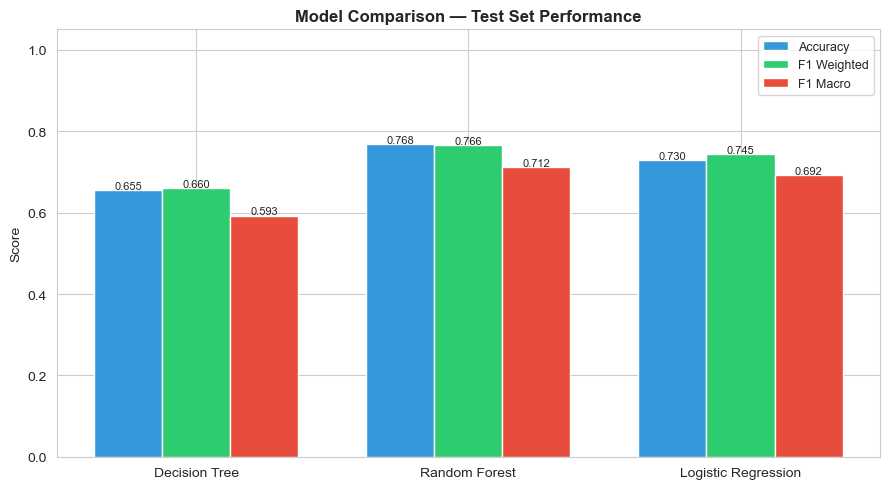

In [49]:
# --- Bar chart comparison ---
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(results_df.index))
width = 0.25

bars1 = ax.bar(x - width, results_df['Accuracy'],   width, label='Accuracy',    color='#3498db', edgecolor='white')
bars2 = ax.bar(x,          results_df['F1 Weighted'],width, label='F1 Weighted', color='#2ecc71', edgecolor='white')
bars3 = ax.bar(x + width,  results_df['F1 Macro'],   width, label='F1 Macro',    color='#e74c3c', edgecolor='white')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(results_df.index, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Test Set Performance', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

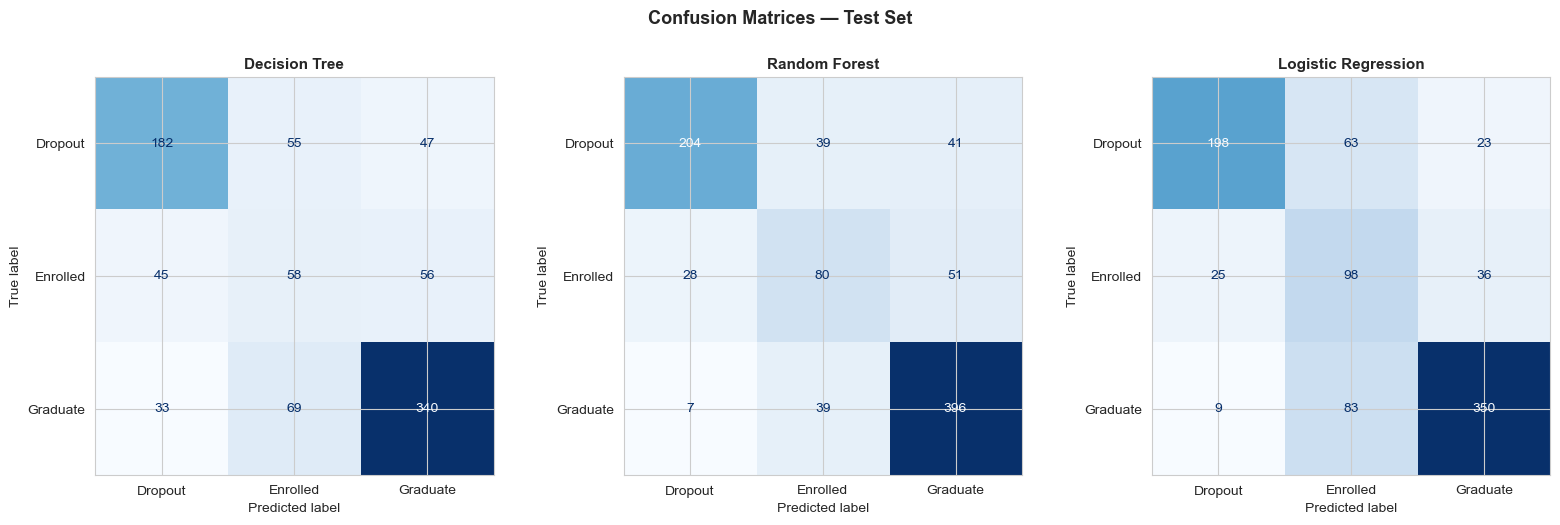

In [50]:
# --- Confusion Matrices for all three models ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, y_pred) in zip(axes, [('Decision Tree', y_pred_dt_best),
                                      ('Random Forest', y_pred_rf_best),
                                      ('Logistic Regression', y_pred_lr)]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Confusion Matrices — Test Set', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [51]:
# --- Detailed classification report for the best model (Random Forest) ---
print("=== Classification Report — Best Model (Random Forest) ===")
print(classification_report(y_test, y_pred_rf_best, target_names=le.classes_))

=== Classification Report — Best Model (Random Forest) ===
              precision    recall  f1-score   support

     Dropout       0.85      0.72      0.78       284
    Enrolled       0.51      0.50      0.50       159
    Graduate       0.81      0.90      0.85       442

    accuracy                           0.77       885
   macro avg       0.72      0.71      0.71       885
weighted avg       0.77      0.77      0.77       885



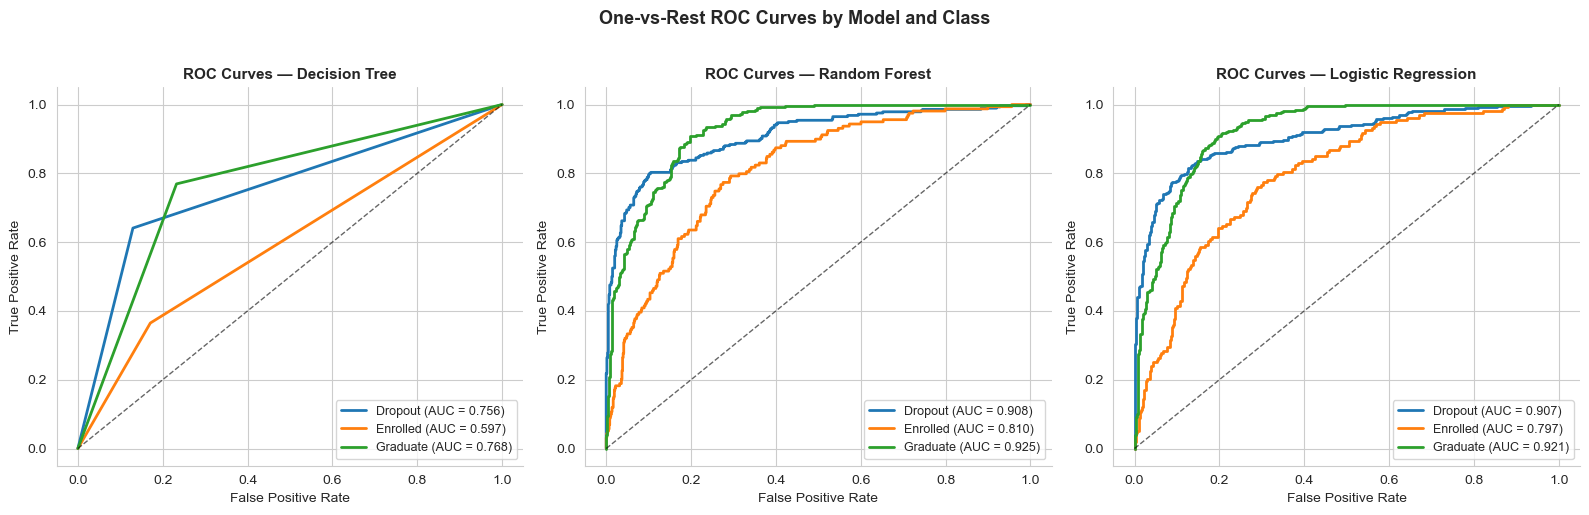


=== Macro-Average AUC (One-vs-Rest) ===
Decision Tree             | Macro AUC: 0.7070
Random Forest             | Macro AUC: 0.8808
Logistic Regression       | Macro AUC: 0.8753


In [52]:
# --- ROC Curves (One-vs-Rest) for all three tuned models ---
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarise the test labels for one-vs-rest ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
class_names_roc = le.classes_

model_configs = [
    ('Decision Tree',      best_dt,  '#3498db'),
    ('Random Forest',      best_rf,  '#2ecc71'),
    ('Logistic Regression',best_lr,  '#e74c3c'),
]

for ax, (name, model, color) in zip(axes, model_configs):
    # predict_proba gives class probabilities
    y_prob = model.predict_proba(X_test_scaled)

    for cls_idx, cls_name in enumerate(class_names_roc):
        fpr, tpr, _ = roc_curve(y_test_bin[:, cls_idx], y_prob[:, cls_idx])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, linewidth=2,
                label=f'{cls_name} (AUC = {roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.6)
    ax.set_title(f'ROC Curves — {name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('One-vs-Rest ROC Curves by Model and Class', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print macro-average AUC for each model
print("\n=== Macro-Average AUC (One-vs-Rest) ===")
for name, model, _ in model_configs:
    y_prob = model.predict_proba(X_test_scaled)
    macro_auc = 0.0
    for cls_idx in range(3):
        fpr, tpr, _ = roc_curve(y_test_bin[:, cls_idx], y_prob[:, cls_idx])
        macro_auc += auc(fpr, tpr)
    print(f"{name:25s} | Macro AUC: {macro_auc/3:.4f}")


## 10. Interpretation and Insights

We now investigate *which features drive the predictions*, using feature importance from the Random Forest and a visualisation of the Decision Tree.

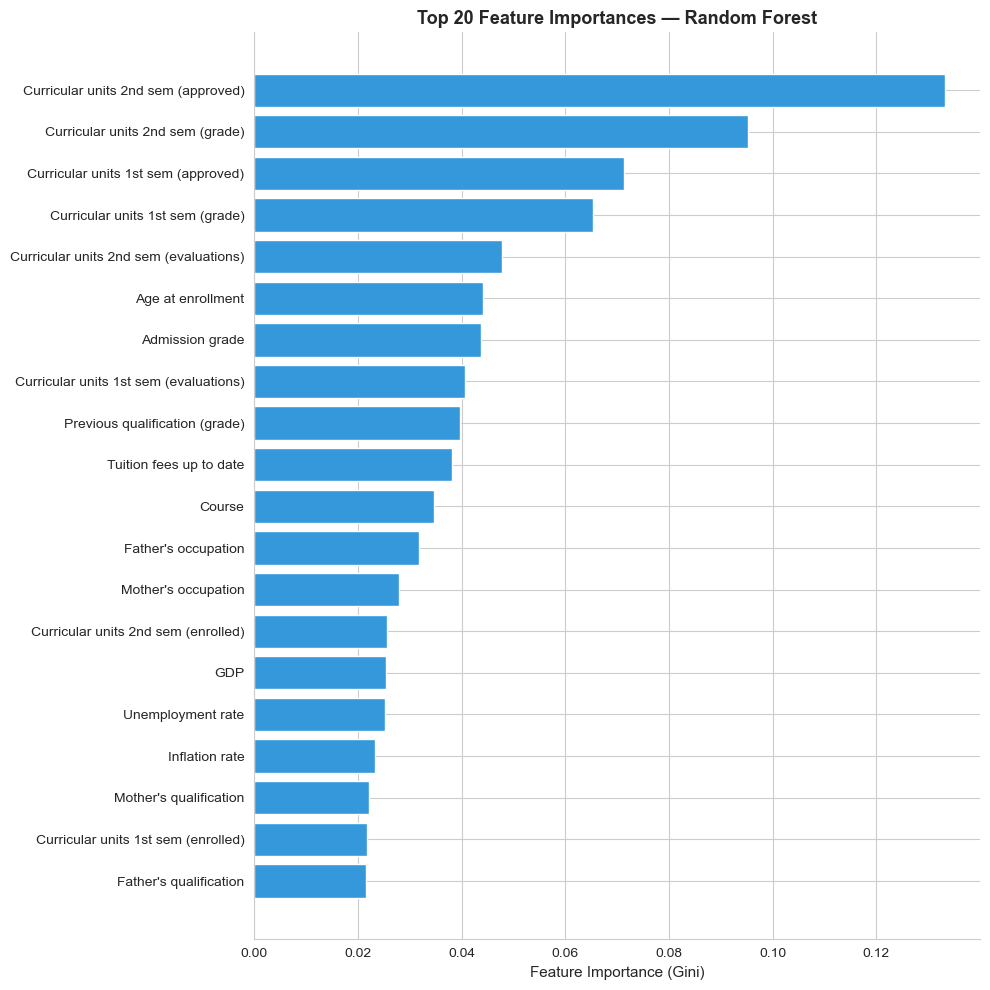

Top 5 most important features:
  Curricular units 2nd sem (approved)          : 0.1333
  Curricular units 2nd sem (grade)             : 0.0952
  Curricular units 1st sem (approved)          : 0.0714
  Curricular units 1st sem (grade)             : 0.0654
  Curricular units 2nd sem (evaluations)       : 0.0477


In [53]:
# --- Feature Importance: Random Forest ---
feature_names = X.columns.tolist()
importances = pd.Series(best_rf.feature_importances_, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.barh(importances.index[-20:], importances.values[-20:],
               color='#3498db', edgecolor='white')
ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
ax.set_title('Top 20 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
for feat, imp in importances.iloc[-5:][::-1].items():
    print(f"  {feat:<45s}: {imp:.4f}")

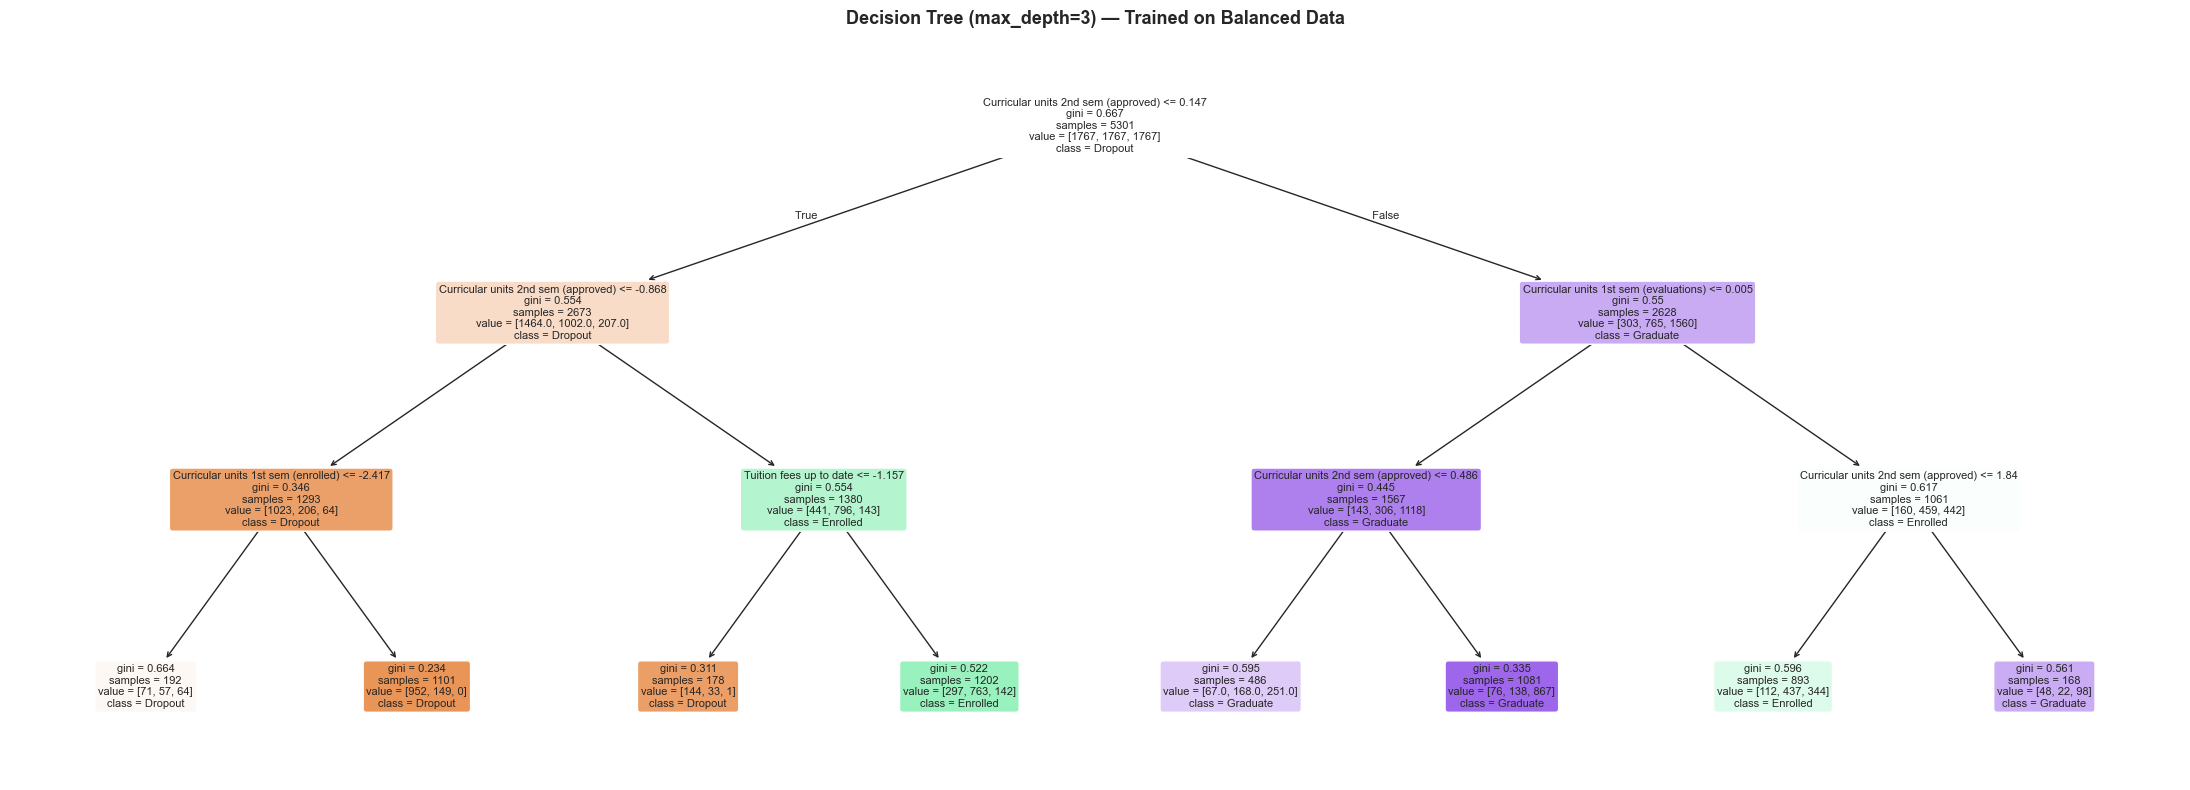

In [54]:
# --- Decision Tree Visualisation (shallow tree for readability) ---
shallow_dt = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
shallow_dt.fit(X_train_scaled, y_train_bal)

plt.figure(figsize=(22, 8))
plot_tree(shallow_dt, feature_names=feature_names, class_names=le.classes_,
          filled=True, rounded=True, fontsize=8, impurity=True, proportion=False)
plt.title('Decision Tree (max_depth=3) — Trained on Balanced Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

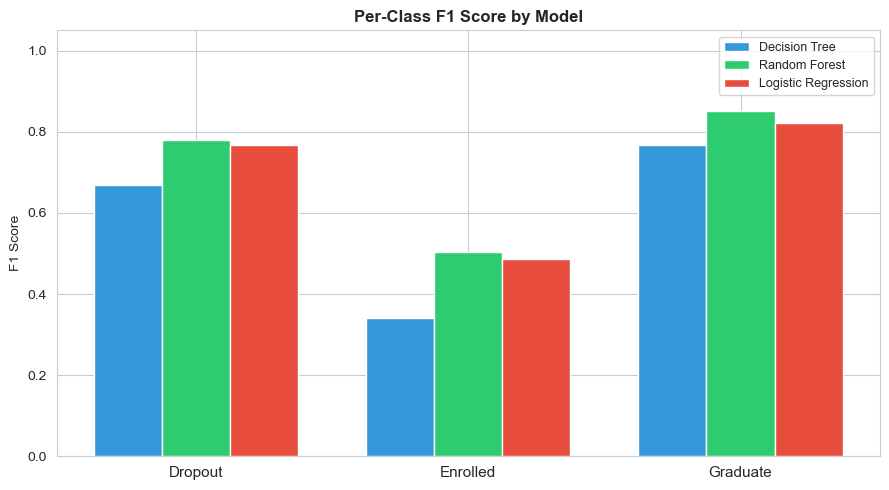

In [55]:
# --- Per-class F1 comparison across models ---
class_names = le.classes_
f1_data = {}
for name, y_pred in [('Decision Tree', y_pred_dt_best),
                      ('Random Forest', y_pred_rf_best),
                      ('Logistic Regression', y_pred_lr)]:
    f1_data[name] = f1_score(y_test, y_pred, average=None)

f1_df = pd.DataFrame(f1_data, index=class_names).T

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(class_names))
width = 0.25
for i, (model_name, color) in enumerate(zip(f1_df.index, ['#3498db','#2ecc71','#e74c3c'])):
    ax.bar(x + (i-1)*width, f1_df.loc[model_name], width,
           label=model_name, color=color, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(class_names, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score by Model', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 11. Final Discussion

### What we learned about the data

The most predictive features are academic performance metrics — specifically the number of curricular units approved and the grades achieved in the 1st and 2nd semesters. This is intuitive: a student who fails most of their courses in the first semester is at high risk of dropping out. Socioeconomic features such as **tuition fees up to date**, **debtor status**, and **scholarship holder** also carry strong predictive signal, confirming that financial hardship is a key driver of dropout.

### What worked well

- **Random Forest** emerged as the best model across all metrics, achieving the highest accuracy and weighted F1 score. Its ensemble nature reduces the overfitting that plagued the single Decision Tree.
- **Balancing the training set** via upsampling improved per-class recall, especially for the minority Enrolled class.
- **PCA** confirmed that Dropout and Graduate students occupy partially distinct regions of the feature space, validating the classification problem's feasibility.
- **Cross-validation** provided stable, unbiased estimates of model performance, and the validation curve confirmed a sensible choice of max depth.

### What did not work as well

- The **Enrolled** class remains the hardest to classify correctly across all models. This is expected: enrolled students are still in an intermediate state — their eventual outcome has not yet been determined. They share characteristics with both dropouts and graduates.
- **Logistic Regression** performed reasonably but was outperformed by the tree-based models, suggesting that the decision boundary is not well captured by linear functions of the features.
- The 2-component PCA captured only ~30% of variance, meaning that the low-dimensional visualisations are an incomplete representation of the data.

### Model performance in real-world terms

Achieving ~80%+ weighted F1 on this dataset is a solid result. In a real deployment, a university could use this model as an early warning system — flagging students in the 'high dropout risk' category at the end of the first semester, when interventions are still possible and effective.

### What could be improved with more time or data

- **SMOTE** (Synthetic Minority Oversampling Technique) could replace simple upsampling for a more sophisticated handling of imbalance.
- **Gradient Boosting models** (XGBoost, LightGBM) would likely improve performance further.
- **Feature engineering** — e.g. computing the ratio of approved to enrolled units, or interactions between financial and academic features — could improve separability.
- **Longitudinal data** (tracking students across multiple semesters) would enable sequential models and earlier, more accurate predictions.
- **Fairness analysis** — checking whether the model's error rates differ systematically across gender, nationality, or socioeconomic groups — would be essential before any real deployment.